In [1]:
import sys, os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
import jax_cosmo.background as bkgrd
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
import jax
import matplotlib
import matplotlib.pyplot as pl
# set latex to false:
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)
import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()
from jax import config
config.update("jax_enable_x64", True)
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import jax.numpy as jnp
import colossus 
from jax import vmap, grad, pmap
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
# Palatino
# pl.rc('font', family='DejaVu Sans')

%matplotlib inline
%load_ext autoreload
%autoreload 2



/tmp/ipykernel_2194284/3212067244.py:5: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  platform = xla_bridge.get_backend().platform


1 1


/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
Cls_path = abs_path_data + f'/DESxACT/ACT_Cls/Cls_ilc_SZ_deproj_cib_cibdBeta_1.7_10.7_yy_apod10arcmin_21Mar24.txt'



Text(0, 0.5, '$C_\\ell \\ \\ell(\\ell+1)/2\\pi$')

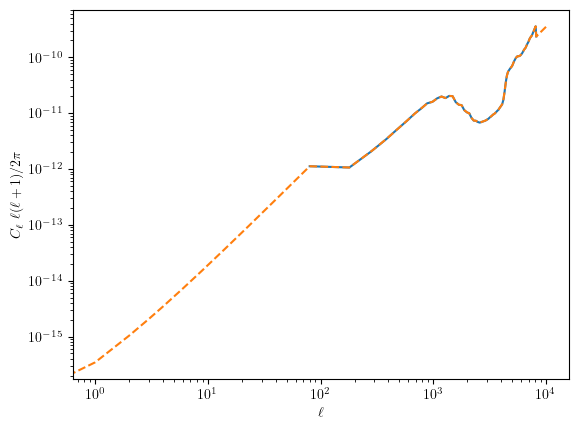

In [17]:
ell_data, Cl_data = np.loadtxt(Cls_path, unpack=True)
ell_max = 10000
ell_map = jnp.arange(0, ell_max + 1)
Cl_interp_func = interp.interp1d(np.log(ell_data), np.log(Cl_data), bounds_error=False, fill_value=(np.array([np.log(Cl_data[0])]), np.array([np.log(Cl_data[-1])])))
Cl_map = jnp.exp(Cl_interp_func(jnp.log(ell_map)))

pl.loglog(ell_data, Cl_data * ell_data * (ell_data + 1) / (2 * np.pi))
pl.loglog(ell_map, Cl_map * ell_map * (ell_map + 1) / (2 * np.pi), '--')
pl.xlabel(r'$\ell$')
pl.ylabel(r'$C_\ell \ \ell(\ell+1)/2\pi$')



In [18]:
import healpy as hp
nside = 1024
map_tSZ_total = hp.synfast(Cl_map, nside=nside, lmax=ell_max, verbose=False)


/tmp/ipykernel_2194284/3177221797.py:3: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  map_tSZ_total = hp.synfast(Cl_map, nside=nside, lmax=ell_max, verbose=False)


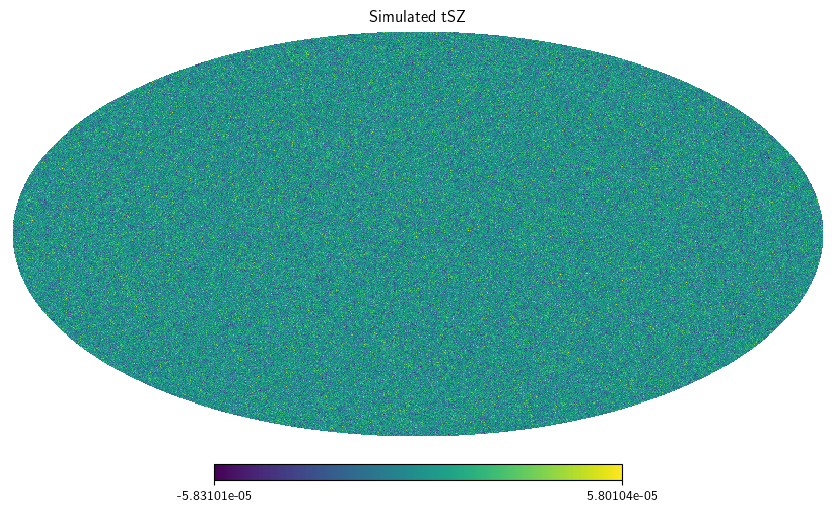

In [19]:
hp.mollview(map_tSZ_total, title='Simulated tSZ')


In [ ]:
from tqdm import tqdm
from base_class import get_vmapped_func, get_vmapped_func_warg, EmptyCallable
from jax import jit, vmap
import interpax
import jax.scipy.integrate as jsi
from tqdm import tqdm
from colossus.cosmology import cosmology as cosmology_colossus
from colossus.halo import mass_defs
from colossus.halo import concentration
from scipy.interpolate import interp1d

saved_bestfit = {}
for jk, key in enumerate(keys):
    # print(key, samps[map_ind, jk])
    saved_bestfit[key] = samps[map_ind, jk]

# potential_energy -4916.635080802822
import yaml
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 

from deepmerge import always_merger
def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

default_data = read_yaml(abs_path_params + '/params_default.yaml')
# new_data = read_yaml(abs_path_params + '/DESxACT/params_v2.yaml')
new_data = read_yaml(abs_path_params + '/Pge/params.yaml')
# new_data = read_yaml(abs_path_params + '/DESxACT/params_v0.yaml')
merged_data = always_merger.merge(default_data, new_data)

sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)


# saved_bestift
from astropy.io import fits
df = fits.open(os.path.abspath(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits'))
z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array_source'] = z_array
nz_info_dict['nbins'] = 4
for ji in range(nz_info_dict['nbins']):
    nz_info_dict['nz'+str(ji)] = np.maximum(df['nz_source'].data['BIN'+str(ji+1)], 1e-4)
analysis_dict['nz_source_info_dict'] = nz_info_dict
other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])


analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]

lmin, lmax, dl_log_array = 10.0, 61000.0, 0.23025851
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
halo_params_dict['ell_array'] = jnp.array(l_array_survey)
analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
analysis_dict['dl_array_survey'] = jnp.array(dl_array)

analysis_dict['beam_fwhm_arcmin'] = 1.6
analysis_dict['beam_fwhm_arcmin'] = 1.6

# for key in saved_bestfit.keys():
#     if key in list(sim_params_dict.keys()):
#         sim_params_dict[key] = float(saved_bestfit[key])
#     if key in list(sim_params_dict['cosmo'].keys()):
#         sim_params_dict['cosmo'][key] = float(saved_bestfit[key])
#         if key == 'h':
#             sim_params_dict['cosmo']['H0'] = 100*saved_bestfit[key]
#     if key in list(other_params_dict.keys()):
#         other_params_dict[key] = float(saved_bestfit[key])
# for jb in range(analysis_dict['nz_source_info_dict']['nbins']):
#     other_params_dict['Delta_z_bias_array'][jb] = saved_bestfit[f'Delta_z_bias_array_{jb}']
# for jb in range(analysis_dict['nz_source_info_dict']['nbins']):
#     other_params_dict['mult_shear_bias_array'][jb] = saved_bestfit[f'mult_shear_bias_array_{jb}']


# sim_params_dict['cosmo']['Om0'] = 0.3
# sim_params_dict['cosmo']['Ob0'] = 0.048
# sim_params_dict['cosmo']['sigma8'] = 0.80
# sim_params_dict['cosmo']['ns'] = 0.96
# sim_params_dict['theta_ej_0'] = 2.0
# sim_params_dict['nu_theta_ej_M'] = -0.33
# sim_params_dict['nu_theta_ej_z'] = -1.22
# halo_params_dict['rmax'] = 12.0
# halo_params_dict['nr'] = 128
# halo_params_dict['nk'] = 96
base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
vmapped_func = get_vmapped_func_warg(Pkz_test.get_P_1h, 2, 4)
Pyy_1h_kz_mat = vmapped_func(jnp.arange(Pkz_test.nk), jnp.arange(Pkz_test.nz), 3, 3).T
Pyy_2h_kz_mat = Pkz_test.by_kz_mat * Pkz_test.by_kz_mat * Pkz_test.plin_kz_mat
Pyy_tot_mat = Pyy_1h_kz_mat + Pyy_2h_kz_mat

print(profiles_test.fstar_tot_mat[10,:])
# Bl_array = jnp.exp(-1. * Pkz_test.ell_array * (Pkz_test.ell_array + 1) * (Pkz_test.sig_beam ** 2) / 2.)
# Bl_mat = Bl_array[:, None]

@jit
def get_P_lz(jl, jz, Pk_mat):
    ell = base_test.ell_array[jl]
    chi_z = base_test.chi_array[jz]
    k_ell = (ell + 0.5)/jnp.clip(chi_z, 1.0)
    Pkz_ell = jnp.exp(jnp.interp(jnp.log(k_ell), jnp.log(base_test.kPk_array), jnp.log(Pk_mat[:,jz])))
    return Pkz_ell

vmapped_func = get_vmapped_func_warg(get_P_lz, 2, 3)
Pkyy_lz_mat = vmapped_func(jnp.arange(base_test.nell), jnp.arange(base_test.nz), Pyy_tot_mat).T

# Pkyy_lz_mat = Pkyy_lz_mat * (Bl_mat**2)
logPkyylz_2d_interp = interpax.Interpolator2D(jnp.log(base_test.ell_array), base_test.z_array, jnp.log(Pkyy_lz_mat), extrap=True)        

@jit
def get_Cl_tot(jl):
    Pk = jnp.exp(logPkyylz_2d_interp(jnp.log(base_test.ell_array[jl]), base_test.z_array_for_Cls))
    Wy_array = (1.0 / (1.0 + base_test.z_array_for_Cls))

    prefac = Wy_array / (base_test.chi_array_for_Cls**2)
    fx = prefac * prefac  * (base_test.chi_array_for_Cls ** 2) * base_test.dchi_dz_array_for_Cls * Pk
    return jsi.trapezoid(fx, x=base_test.z_array_for_Cls)     

Cl_yy = vmap(get_Cl_tot)(jnp.arange(base_test.nell))
fach = 1e12*((base_test.ell_array)*(base_test.ell_array + 1) / (2 * np.pi))